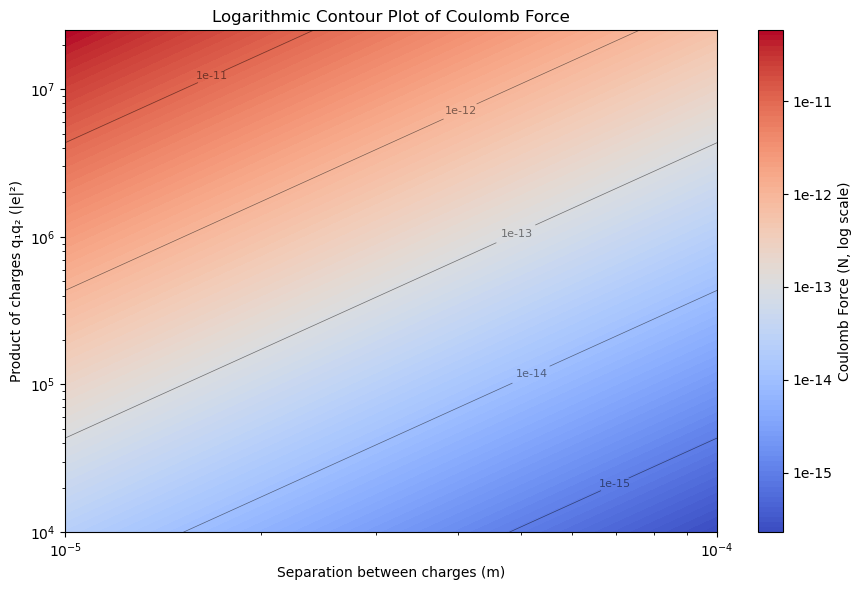

In [7]:
import numpy as np
from matplotlib.colors import LogNorm

import matplotlib.pyplot as plt

# Coulomb constant (N·m²/C²)
k = 8.9875517923e9

# Axes:
# x -> separation distance (m)
# y -> product of charges q1*q2 (C²)
separation = np.linspace(10e-6, 100e-6, 400)      # avoid 0 to prevent division by zero
elementary_charge = 1.602176634e-19  # C

# Express charge product as the product of electron counts (n1 * n2)
charge_product = np.linspace(100*100, 5000*5000, 20000)

R, Qprod = np.meshgrid(separation, charge_product)

# Coulomb force: F = k * (n1*n2*e^2) / r^2
F = k * (Qprod * elementary_charge ** 2) / (R ** 2)

plt.figure(figsize=(9, 6))
levels = np.logspace(np.log10(F.min()), np.log10(F.max()), 100)

contour = plt.contourf(R, Qprod, F, levels=levels, norm=LogNorm(), cmap="coolwarm")
plt.colorbar(contour, label="Coulomb Force (N, log scale)")

# Build contour/colorbar ticks at decade values based on the current force range
fmin = np.nanmin(F[F > 0])  # LogNorm requires positive values
fmax = np.nanmax(F)

min_exp = int(np.floor(np.log10(fmin)))
max_exp = int(np.ceil(np.log10(fmax)))

tick_vals = 10.0 ** np.arange(min_exp, max_exp + 1)
tick_vals = tick_vals[(tick_vals >= fmin) & (tick_vals <= fmax)]

line_contours = plt.contour(
    R,
    Qprod,
    F,
    levels=tick_vals,
    norm=LogNorm(),
    colors="black",
    linewidths=0.5,
    alpha=0.5,
)

# Place contour labels at safe interior positions
x_lo, x_hi = separation.min() * 1.15, separation.max() / 1.15
q_lo, q_hi = charge_product.min() * 1.20, charge_product.max() / 1.20

manual_positions = []
for lvl in tick_vals:
    q_on_level = (lvl * separation**2) / (k * elementary_charge**2)
    mask = (
        (separation >= x_lo) & (separation <= x_hi) &
        (q_on_level >= q_lo) & (q_on_level <= q_hi)
    )
    if np.any(mask):
        xs = separation[mask]
        ys = q_on_level[mask]
        mid = len(xs) // 2
        manual_positions.append((xs[mid], ys[mid]))

texts = plt.clabel(
    line_contours,
    fmt={v: f"{v:.0e}" for v in tick_vals},
    inline=True,
    fontsize=8,
    manual=manual_positions if manual_positions else None,
)

for txt in texts:
    txt.set_rotation(0)

for t in texts:
    t.set_clip_on(True)

cbar_ax = plt.gcf().axes[-1]  # colorbar axis
cbar_ax.set_yticks(tick_vals)
cbar_ax.set_yticklabels([f"{v:.0e}" for v in tick_vals])

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Separation between charges (m)")
plt.ylabel("Product of charges q₁q₂ (|e|²)")
plt.title("Logarithmic Contour Plot of Coulomb Force")
plt.tight_layout()
plt.show()